In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_csv("../data/raw/churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df.shape

(2666, 20)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [5]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

In [7]:
df['International plan'] = df['International plan'].map({'yes': 1, 'no': 0})

In [8]:
df['Voice mail plan'] = df['Voice mail plan'].map({'yes': 1, 'no': 0})

In [9]:
df['Churn'] = df['Churn'].astype(int)

In [10]:
print(df[['International plan', 'Voice mail plan', 'Churn']].dtypes)

International plan    float64
Voice mail plan       float64
Churn                   int64
dtype: object


In [11]:
# Checking if Minutes and Charge are essentially the same thing
correlation_pairs = [
    ['Total day minutes', 'Total day charge'],
    ['Total eve minutes', 'Total eve charge'],
    ['Total night minutes', 'Total night charge']
]

for pair in correlation_pairs:
    print(f"Correlation for {pair}: {df[pair].corr().iloc[0,1]:.4f}")

Correlation for ['Total day minutes', 'Total day charge']: 1.0000
Correlation for ['Total eve minutes', 'Total eve charge']: 1.0000
Correlation for ['Total night minutes', 'Total night charge']: 1.0000


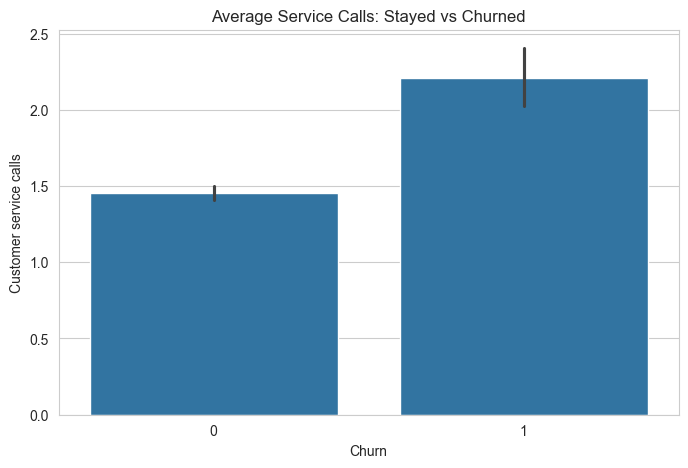

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Churn', y='Customer service calls', data=df)
plt.title('Average Service Calls: Stayed vs Churned')
plt.show()

In [13]:
# Drop redundant charge columns
cols_to_drop = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
df.drop(columns=cols_to_drop, inplace=True)

# Verify
print(f"New shape: {df.shape}")
print(df.columns)

New shape: (2666, 16)
Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total eve minutes', 'Total eve calls',
       'Total night minutes', 'Total night calls', 'Total intl minutes',
       'Total intl calls', 'Customer service calls', 'Churn'],
      dtype='str')


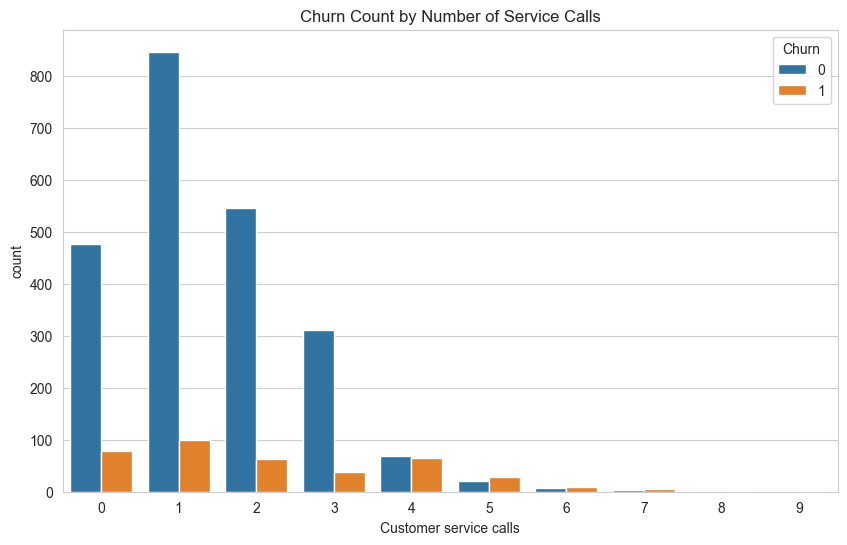

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(x='Customer service calls', hue='Churn', data=df)
plt.title('Churn Count by Number of Service Calls')
plt.show()

### Key Insight: The "Customer Service Call" Tipping Point
The distribution of churn reveals a clear **"Danger Zone"** starting at 4 service calls:

* **Safe Zone (0-3 calls):** High customer retention. The majority of the user base falls here, and churn is relatively low.
* **The Critical Threshold (4 calls):** This is the pivot point. The probability of churn increases dramatically to roughly **50%**.
* **The Exit Zone (5+ calls):** The "Churn" bars surpass the "Stayed" bars. At this stage, a customer is statistically more likely to leave than stay.

**Recommendation:** Business logic should trigger a "Retention Offer" or escalate to a senior representative once a customer reaches their **3rd or 4th call**.